> 当前业界（特别是 DeepSeek 的 GRPO ）开始流行将 KL 散度作为一个独立的 Loss 项（"as loss"），而非像 PPO 那样放在 Reward 中（"in reward"）。

- grpo vs. ppo: $r(x)=\frac{\pi_\text{ref}(x)}{\pi_\theta(x)}$
    - ppo: k1 in reward, $R_t'=R_t-\beta k_1(t)$
        - $-\log r(x)$
    - grpo: k3 as loss
        - $k_3(x)=r(x)-1-\log r(x)$
        - 一节泰勒展开($\log x<x-1$)，保证非负 
    - $k_2(x)=\frac12(r(x))^2$
- reverse or forward
    - $KL(\pi_\theta || \pi_{ref})=\mathbb{E}_{x \sim \pi_\theta} [\log \frac{\pi_\theta(x)}{\pi_{ref}(x)}]$: mode seeking
        - 期望是基于当前策略 $\pi_\theta$ 采样生成数据来更新模型，这属于 On-Policy 采样，计算梯度非常自然且方便 。
    - $KL(\pi_\theta || \pi_{ref})=\mathbb{E}_{x \sim \pi_{ref}} [\log \frac{\pi_{ref}(x)}{\pi_\theta(x)}]$: Zero-forcing / Mean-seeking
- refs
    - http://joschu.net/blog/kl-approx.html

$$
\begin{aligned}
L_{k3} &= \underbrace{\left( \frac{\pi_{ref}}{\pi_\theta} - 1 \right)}_{\text{上界 (Upper Bound)}} - \underbrace{\log \left( \frac{\pi_{ref}}{\pi_\theta} \right)}_{\text{真值 (Log Value)}} \\
&= \frac{\pi_{ref}}{\pi_\theta} - 1 - \log \frac{\pi_{ref}}{\pi_\theta}
\end{aligned}
$$
- 期望意义上 $\mathbb{E}_{x \sim \pi} [k_3(x)] = \mathbb{E}_{x \sim \pi} \left[ \frac{\pi_{ref}(x)}{\pi(x)} - 1 - \log \frac{\pi_{ref}(x)}{\pi(x)} \right]=D_{KL}(\pi \| \pi_{ref})$
- 函数 $f(t) = t - 1 - \log t$（其中 $t = \pi_{ref}/\pi$）具有以下优良的数学性质：
    - 非负性：$f(t) \ge 0$，最小值在 $t=1$ 处取到 0。
    - 凸性（Convexity）：求二阶导数，二阶导数恒大于 0，说明这是一个严格凸函数。
      $$f'(t) = 1 - \frac{1}{t}, \quad f''(t) = \frac{1}{t^2} > 0$$
    - 二阶匹配：在 $t=1$（即 $\pi = \pi_{ref}$）附近，它的二阶泰勒展开与标准 KL 散度完全一致。

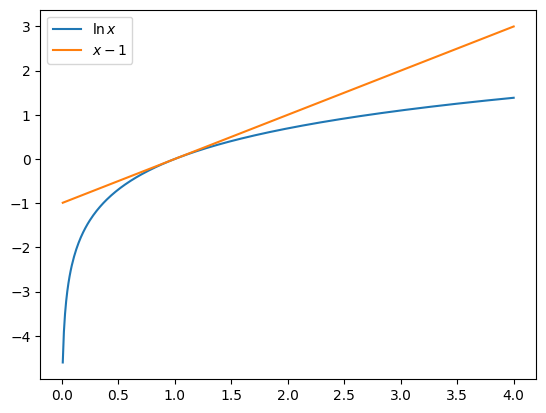

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 4, 400)
y_log = np.log(x)      # ln x
y_line = x - 1         # x - 1
plt.plot(x, y_log, label=r'$\ln x$')
plt.plot(x, y_line, label=r'$x - 1$')
plt.legend()

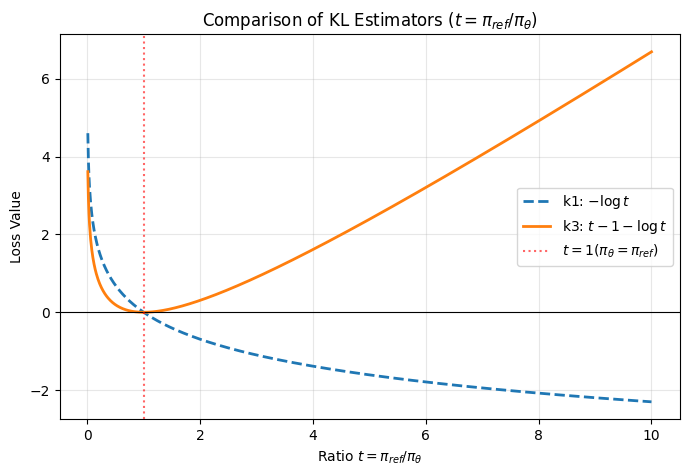

In [21]:

x = np.linspace(0.01, 10, 1000)
k1 = -np.log(x)              # Standard KL term
k3 = x - 1 - np.log(x)       # k3 Estimator

plt.figure(figsize=(8, 5))
plt.plot(x, k1, label=r'k1: $-\log t$', linewidth=2, linestyle='--')
plt.plot(x, k3, label=r'k3: $t - 1 - \log t$', linewidth=2)

# 添加参考线
plt.axhline(0, color='black', linewidth=0.8) # y=0
plt.axvline(1, color='red', linestyle=':', alpha=0.6, label=r'$t=1 (\pi_\theta=\pi_{ref})$') # x=1

plt.title(r'Comparison of KL Estimators ($t = \pi_{ref} / \pi_\theta$)')
plt.xlabel(r'Ratio $t = \pi_{ref} / \pi_\theta$')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

### estimation

In [4]:
# [Batch, Seq, Vocab]
32 * 2048 * 128000 * 4 / (1024 * 1024 * 1024) * 2

62.5

In [5]:
# [Batch, Seq, Vocab] -> [Batch, Seq]

In [9]:
import torch
import torch.distributions as dist
import pandas as pd
import numpy as np

torch.manual_seed(42)

# 1. 定义分布
# Reference (P): 标准正态分布 N(0, 1)
# Actor (Q): 窄正态分布 N(0.1, 0.2) -> 模拟模型过度自信或坍缩的情况
p_ref = dist.Normal(loc=0.0, scale=1.0)
q_actor = dist.Normal(loc=0.1, scale=0.2)

print(f"--- Experiment Setup ---")
print(f"Reference Policy (P): N(0, 1)")
print(f"Actor Policy (Q):     N(0.1, 0.2)  <-- Narrower (Variance explodes?)")

# 2. 计算真实 KL 值 (Ground Truth)
# KL(Q || P) = E_x~Q [log Q - log P]
true_kl = dist.kl_divergence(q_actor, p_ref).item()
print(f"True KL(Q || P):      {true_kl:.4f}\n")

# 3. 采样 (On-Policy Sampling from Actor Q)
N_SAMPLES = 10000
x = q_actor.sample((N_SAMPLES,))

# 4. 计算概率比 (Importance Ratio)
# r = P(x) / Q(x)
# 注意：很多论文定义 ratio = pi / ref，这里为了复现 k3 (GRPO) 的公式 r - log r - 1，
# 我们需要明确 r 是什么。
# GRPO 的 k3 = (ref/pi) - 1 - log(ref/pi). 
# Liu et al. 定义 delta = ref / pi. 
# PPO 的 k1 = log(pi/ref) = -log(delta).

log_prob_q = q_actor.log_prob(x)
log_prob_p = p_ref.log_prob(x)

# log_ratio = log(pi / ref)
log_ratio_pi_ref = log_prob_q - log_prob_p

# ratio_ref_pi = ref / pi (用于 k3)
ratio_ref_pi = torch.exp(log_prob_p - log_prob_q)

# 5. 计算三种估计器

# k1: Standard Log Ratio (PPO)
# Estimator: log(pi/ref)
# Expectation: KL(Q||P) -> Unbiased
k1_est = log_ratio_pi_ref

# k2: Squared Log Ratio (Liu et al. Recommended as Loss)
# Estimator: 0.5 * (log(pi/ref))^2
# Expectation: Not KL. It's second moment.
k2_est = 0.5 * (log_ratio_pi_ref ** 2)

# k3: Unnormalized KL (GRPO)
# Estimator: (ref/pi) - 1 - log(ref/pi)
# Note: log(ref/pi) = -log(pi/ref)
k3_est = ratio_ref_pi - 1 - (-log_ratio_pi_ref)

# 6. 统计 Bias 和 Variance
results = []

for name, est, is_kl_estimator in [
    ("k1 (PPO)", k1_est, True),
    ("k2 (RKL-Loss)", k2_est, False),
    ("k3 (GRPO)", k3_est, True)
]:
    mean_val = est.mean().item()
    std_val = est.std().item()
    
    # Bias 只有对旨在估计 KL 的估计器才有意义
    bias = (mean_val - true_kl) if is_kl_estimator else np.nan
    
    results.append({
        "Estimator": name,
        "Sample Mean": f"{mean_val:.4f}",
        "True KL": f"{true_kl:.4f}" if is_kl_estimator else "(Not KL)",
        "Bias": f"{bias:.4f}" if is_kl_estimator else "N/A",
        "Std Dev (Variance)": f"{std_val:.4f}"
    })
    
df = pd.DataFrame(results)
print(df.to_markdown(index=False))

print("\n--- Analysis ---")
print("1. k1 (PPO):   Unbiased (Bias near 0), Moderate Variance.")
print("2. k2 (Loss):  Value is NOT KL (Bias is N/A), but Variance is smallest.")
print("               (Liu et al. prove its GRADIENT is unbiased for RKL, not its value)")
print("3. k3 (GRPO):  Theoretically unbiased for UKL, BUT Variance explodes!")
print("               Notice the Std Dev is huge compared to k1.")
print("               This happens because P/Q ratio explodes in the tails.")

--- Experiment Setup ---
Reference Policy (P): N(0, 1)
Actor Policy (Q):     N(0.1, 0.2)  <-- Narrower (Variance explodes?)
True KL(Q || P):      1.1344

| Estimator     |   Sample Mean | True KL   | Bias    |   Std Dev (Variance) |
|:--------------|--------------:|:----------|:--------|---------------------:|
| k1 (PPO)      |        1.1303 | 1.1344    | -0.0041 |               0.6739 |
| k2 (RKL-Loss) |        0.8658 | (Not KL)  | N/A     |               0.5688 |
| k3 (GRPO)     |        0.7749 | 1.1344    | -0.3595 |               9.8543 |

--- Analysis ---
1. k1 (PPO):   Unbiased (Bias near 0), Moderate Variance.
2. k2 (Loss):  Value is NOT KL (Bias is N/A), but Variance is smallest.
               (Liu et al. prove its GRADIENT is unbiased for RKL, not its value)
3. k3 (GRPO):  Theoretically unbiased for UKL, BUT Variance explodes!
               Notice the Std Dev is huge compared to k1.
               This happens because P/Q ratio explodes in the tails.


### gradient

$$
J_{RKL}(\theta) = \sum_x \pi_\theta(x) \log \frac{\pi_\theta(x)}{\pi_{ref}(x)}
$$
$$
\nabla_\theta J_{RKL} = \sum_x \left[ \nabla_\theta \pi_\theta(x) \cdot \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} + \pi_\theta(x) \cdot \nabla_\theta \left( \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right) \right]
$$
- 对于第二项
    - $\nabla_\theta \left( \log \pi_\theta(x) - \log \pi_{ref}(x) \right) = \nabla_\theta \log \pi_\theta(x) \quad (\text{因 } \pi_{ref} \text{ 与 } \theta \text{ 无关})$
    - $\sum_x \pi_\theta(x) \nabla_\theta \log \pi_\theta(x) = \sum_x \pi_\theta(x) \frac{\nabla_\theta \pi_\theta(x)}{\pi_\theta(x)} = \sum_x \nabla_\theta \pi_\theta(x) = \nabla_\theta \sum_x \pi_\theta(x) = \nabla_\theta (1) = 0$
    - 第二项的期望贡献为 0 。
$$
\text{Term 1} = \sum_x \pi_\theta(x) \nabla_\theta \log \pi_\theta(x) \cdot \log \frac{\pi_\theta(x)}{\pi_{ref}(x)}
$$
$$
\mathbb{E}_{x \sim \pi_\theta} \left[ \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \cdot \nabla_\theta \log \pi_\theta(x) \right]
$$
$$
\nabla_\theta J_{RKL} = \mathbb{E}_{x \sim \pi_\theta} \left[ \underbrace{\log \frac{\pi_\theta(x)}{\pi_{ref}(x)}}_{\text{Coefficient}} \cdot \nabla_\theta \log \pi_\theta(x) \right]
$$

- 也有的地方：$\mathbb{E}[\nabla \log \pi]=0$

$$
\begin{aligned}
\nabla_{\theta} D_{KL} &= \sum_{x} \left( \pi_{\theta}(x) \cdot \nabla_{\theta} \log \pi_{\theta}(x) \right) \left[ 1 + \log \frac{\pi_{\theta}(x)}{\pi_{ref}(x)} \right] \\
&= \mathbb{E}_{x \sim \pi_{\theta}} \left[ \nabla_{\theta} \log \pi_{\theta}(x) \cdot \left( 1 + \log \frac{\pi_{\theta}(x)}{\pi_{ref}(x)} \right) \right]
\end{aligned}
$$

> 推导 $k_3$

$$
L_{k3}(\theta) = \frac{\pi_{ref}}{\pi_\theta} - 1 - \log \frac{\pi_{ref}}{\pi_\theta}
$$
- 第一项
    - $\nabla_\theta (\pi_{ref} \pi_\theta^{-1}) = -\pi_{ref} \pi_\theta^{-2} \nabla_\theta \pi_\theta = -\frac{\pi_{ref}}{\pi_\theta} \frac{\nabla_\theta \pi_\theta}{\pi_\theta} = -\frac{\pi_{ref}}{\pi_\theta} \nabla_\theta \log \pi_\theta$
- 第三项：
    - $-\log \frac{\pi_{ref}}{\pi_\theta} = \log \pi_\theta - \log \pi_{ref}$
- $\nabla_\theta L_{k3} = \left( 1 - \frac{\pi_{ref}}{\pi_\theta} \right) \nabla_\theta \log \pi_\theta$
- 梯度系数是 $1 - \frac{\pi_{ref}}{\pi_\theta}$，而不是 $\log \frac{\pi_\theta}{\pi_{ref}}$
    - 从 taylor 展开的角度：$-\log x \approx 1-x$
    - 其他的工作中也叫：Unnormalized KL
- 当 $\pi_\theta \ll \pi_{ref}$ 时，未修正的 K3 估计器会导致问题：
    - `In such cases, the gradient of the K3 estimator assigns disproportionately large, unbounded weights to maximize the likelihood of these tokens...`
    - $-\infty \cdot \nabla_\theta \log \pi_\theta$

#### 引入 Importance Ratio (Off-Policy) 的推导证明

$$
D_{KL}(\pi_{\theta} || \pi_{ref}) = \sum_{x} \pi_{\theta}(x) \log \left( \frac{\pi_{\theta}(x)}{\pi_{ref}(x)} \right) = \mathbb{E}_{x \sim \pi_{\theta}} \left[ \log \frac{\pi_{\theta}(x)}{\pi_{ref}(x)} \right]
$$
- 在 GRPO 或 PPO 等强化学习过程中，数据是旧策略 $\pi_{old}$ 采样生成的（Rollout data），而不是当前正在更新参数的 $\pi_{\theta}$。
- 如果我们直接用这些样本计算平均值（即蒙特卡洛估计），不加比率，我们实际上是在计算：
$$
\frac{1}{N} \sum_{i=1}^{N} \log \frac{\pi_{\theta}(x_i)}{\pi_{ref}(x_i)} \xrightarrow{N \to \infty} \mathbb{E}_{x \sim \pi_{old}} \left[ \log \frac{\pi_{\theta}(x)}{\pi_{ref}(x)} \right]
$$

- $\mathbb{E}_{x \sim \pi_{\theta}} [...] \neq \mathbb{E}_{x \sim \pi_{old}} [...]$  
- 关于重要性采样：（$\mathbb{E}_{P}[f(x)] = \mathbb{E}_{Q}[\frac{P(x)}{Q(x)}f(x)]$）

$$
\begin{aligned}
J &= \sum_{x} \pi_{\theta}(x) f(x) \\
&= \sum_{x} \pi_{old}(x) \frac{\pi_{\theta}(x)}{\pi_{old}(x)} f(x) \quad \text{(分子分母同乘 } \pi_{old}) \\
&= \mathbb{E}_{x \sim \pi_{old}} \left[ \frac{\pi_{\theta}(x)}{\pi_{old}(x)} f(x) \right]
\end{aligned}
$$
- 正确的无偏估计量（Unbiased Estimator）应该是：
    - $\text{Loss} \approx \frac{1}{N} \sum_{i=1}^{N} \underbrace{\frac{\pi_{\theta}(x_i)}{\pi_{old}(x_i)}}_{\text{Ratio}} \cdot \left( \text{KL term} \right)$
    - K3 估计器原本是设计用于 On-policy（同策略）场景的，假设采样分布等于当前分布。
    - GRPO 的 KL 项在 Off-Policy 下存在偏差 (Bias)

### verl